<a href="https://colab.research.google.com/github/Danae-Munoz/Analisis_Data_Mineria-de-datos/blob/main/Evaluaci%C3%B3n_3_Danae_Mu%C3%B1oz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Calificación y precio del vino - Evaluación de Minería de Datos**


## Información del Grupo

- **Nombre o Número de Grupo: 10**
- **Sección: 002D**
- **Fecha de Entrega:24/05/2026**


## Integrante del Grupo

- **Nombre: Danae**
- **Apellido: Muñoz Opitz**
- **Correo institucional: dana.munozo@duocuc.cl**

**URL:** https://www.kaggle.com/datasets/budnyak/wine-rating-and-price

---

# **1. Comprensión del Negocio**

## Tema del Proyecto
A partir del análisis del dataset obtenido desde Vivino.com, se observa una alta variabilidad en los precios de los vinos, junto con diferencias en características como la calificación (Rating), la cantidad de valoraciones (NumberOfRatings), el año de producción (Year), el país de origen (Country) y el tipo de vino (WineStyle).

Sin embargo, no siempre resulta evidente cómo estas variables influyen en el precio final del producto, especialmente considerando que vinos con características similares pueden presentar diferencias importantes de valor en el mercado.

En este contexto, surge la necesidad de comprender mejor los factores que determinan el precio de un vino, por lo que se propone el desarrollo de un modelo de aprendizaje automático capaz de predecir el precio en función de sus características disponibles.

Este enfoque permite identificar patrones dentro de los datos, estimar precios de manera más objetiva y apoyar la toma de decisiones en escenarios donde existe poca información o baja visibilidad del producto.


## Descripción del Proyecto
El proyecto tiene como propósito analizar el comportamiento del mercado vitivinícola utilizando información obtenida desde la plataforma Vivino.com, con el fin de identificar las variables que influyen en el precio de los vinos y desarrollar un modelo predictivo basado en machine learning.

Este modelo puede resultar útil para consumidores, distribuidores, tiendas especializadas o plataformas de venta de vinos, ya que permitiría estimar precios de forma automática considerando características como el país, el tipo de vino, el rating, el año y la popularidad del producto.

Además de la predicción, el análisis busca comprender las relaciones existentes entre las variables del dataset, detectar patrones de mercado y evaluar qué factores tienen mayor impacto en el valor final de un vino.



# **Importación de Librerias**

In [ ]:
# Importación de las librerías necesarias
# Librería para manipulación y análisis de datos en tablas (DataFrames)
import pandas as pd
# Librería para operaciones matemáticas y manejo de arreglos numéricos
import numpy as np
# Librería para crear gráficos básicos (histogramas, líneas, etc.)
import matplotlib.pyplot as plt
# Librería basada en matplotlib para visualizaciones estadísticas más avanzadas
import seaborn as sb
# Herramienta para estandarizar variables numéricas (media 0, desviación 1)
from sklearn.preprocessing import StandardScaler
# Técnica para convertir variables categóricas en variables numéricas binarias
from sklearn.preprocessing import OneHotEncoder

* Se utilizaron diversas librerías de Python para el desarrollo del proyecto, incluyendo herramientas para manipulación de datos (pandas), operaciones numéricas (numpy), visualización de datos (matplotlib y seaborn), y técnicas de preprocesamiento como la estandarización de variables (StandardScaler) y la codificación de variables categóricas (OneHotEncoder).



# **Carga, integración y preparación del dataset**

In [ ]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Ruta del archivo en Google Drive
ruta = '/content/drive/MyDrive/mineriadf/df_final.csv'


In [ ]:
# Cargar dataframe
df_final = pd.read_csv(ruta)
df_final.head()


In [ ]:
# Devuelve la cantidad de filas y columnas respectivamente
df_final.shape

* Estos métodos permiten visualizar la estructura del DataFrame, identificando que el dataset cuenta con 13.834 filas y 9 columnas, sin presencia de valores nulos. Además, se observa una combinación de variables numéricas y categóricas, lo que requerirá un preprocesamiento posterior.

In [ ]:
# Visualizamos las primeras 5 filas del DataFrame
df_final.head()

* Se muestran las primeras cinco filas del dataset, donde es posible observar las distintas variables disponibles.

In [ ]:
# Visualizamos las ultimas 5 filas del DataFrame
df_final.tail()

* Se visualizaron las últimas cinco filas del dataset.

In [ ]:
# Observamos la columna y sus tipos de datos
df_final.dtypes

* Mediante el uso del método dtypes, se pudo observar el tipo de dato de cada una de las variables presentes en el dataset.

# **Mapeo de datos**
* Country: Categórico Nominal
* Rating (Calificación promedio): Numérico Continuo
* NumberOfRatings (Número de personas que calificaron este vino): Numérico Discreto
* Price (Precio en EUR): Numérico Continuo
* Year(Año de producción): Numérico Discreto
* WineStyle: Categórico Nominal



**Clasificación de Variables**

* **Categórico Nominal:** Categorías sin un orden o jerarquía específica.
  * Ejemplo: Country, WineStyle.

* **Categórico Ordinal:** Categorías que siguen un orden lógico o escala.
  * Ejemplo: (En este dataset no se identifican variables ordinales explícitas)

* **Numérico Discreto:** Valores que surgen de un conteo y no admiten decimales.
  * Ejemplo: NumberOfRatings, Year.

* **Numérico Continuo:** Valores que resultan de una medición y pueden tener decimales infinitos.
  * Ejemplo: Price, Rating.


---



# **6. Entrenamiento y Evaluación**

In [ ]:
# Importamos librerías necesarias
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Importamos el modelo de Árbol de Decisión
from sklearn.tree import DecisionTreeRegressor


#**Modelado 3:** Random Forest Regressor


In [224]:
# Importamos Random Forest
from sklearn.ensemble import RandomForestRegressor

# Variables independientes
X = df_final.drop(columns=['Price'])

# Variable objetivo con transformación logarítmica
y = np.log1p(df_final['Price'])

# División entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.7,
    random_state=100
)

# Creamos el modelo Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=100,
    n_jobs=-1
)

# Entrenamos el modelo
rf.fit(X_train, y_train)

# Predicciones
y_pred_log = rf.predict(X_test)

# Volvemos a escala original
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

# Evitamos negativos
y_pred = np.maximum(y_pred, 0)

* Se implementó un modelo Random Forest Regressor utilizando múltiples árboles de decisión para predecir el precio de los vinos. La variable objetivo fue transformada mediante log1p para reducir el impacto de valores extremos y mejorar el rendimiento del modelo.

* Posteriormente, las predicciones fueron transformadas nuevamente a su escala original utilizando expm1, permitiendo interpretar los resultados en euros.

In [225]:
# Calculamos el Error Absoluto Medio (MAE)
# Indica cuánto se equivoca el modelo en promedio
mae = mean_absolute_error(y_test_original, y_pred)

# Calculamos el Error Cuadrático Medio (MSE)
# Penaliza más los errores grandes
mse = mean_squared_error(y_test_original, y_pred)

# Calculamos la Raíz del Error Cuadrático Medio(MSE) (RMSE)
# Representa el error promedio en la misma escala del precio (€)
rmse = np.sqrt(mse)

# Calculamos el coeficiente de determinación (R²)
# Mide qué porcentaje de la variabilidad del precio explica el modelo
r2 = r2_score(y_test_original, y_pred)

# Mostramos los resultados obtenidos
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 13.943249829113883
MSE: 2411.1811373320575
RMSE: 49.103779257120905
R2: 0.5378640007776925


* El modelo Random Forest Regressor presentó el mejor desempeño entre los tres modelos evaluados. Obtuvo un MAE de 13,94, lo que indica que, en promedio, sus predicciones se desvían aproximadamente 13,94 € del precio real. Además, alcanzó un R² de 0,5376, por lo que logra explicar cerca del 53,76% de la variabilidad del precio del vino. Esto demuestra que el modelo tiene una mejor capacidad predictiva, ya que combina múltiples árboles de decisión y logra capturar relaciones más complejas entre las variables.

In [226]:
# Comparamos precios reales y predichos
comparacion = pd.DataFrame({
    'Precio real': y_test_original,
    'Precio predicho': y_pred
})

comparacion.head(10)

,Precio real,Precio predicho
1206,25.02,10.675939
6016,25.12,12.921368
3867,11.19,7.560024
11382,27.50,29.220178
3603,8.40,9.478488
379,39.90,45.484094
11757,7.36,16.232060
7679,57.72,35.164924
9818,9.99,8.825704
5638,131.60,51.973509


* La tabla compara los precios reales con los precios predichos por el modelo Random Forest Regressor. Se observa que el modelo logra acercarse correctamente en algunos casos, como en el vino de 27,50 €, donde predice 29,22 €, y en el vino de 39,90 €, donde predice 45,48 €. Sin embargo, presenta diferencias importantes en valores más altos, como el caso del vino de 131,60 €, donde predice 51,97 €. Esto indica que el modelo tiene un mejor comportamiento general que los anteriores, pero aún presenta dificultades para estimar precios extremos o atípicos.

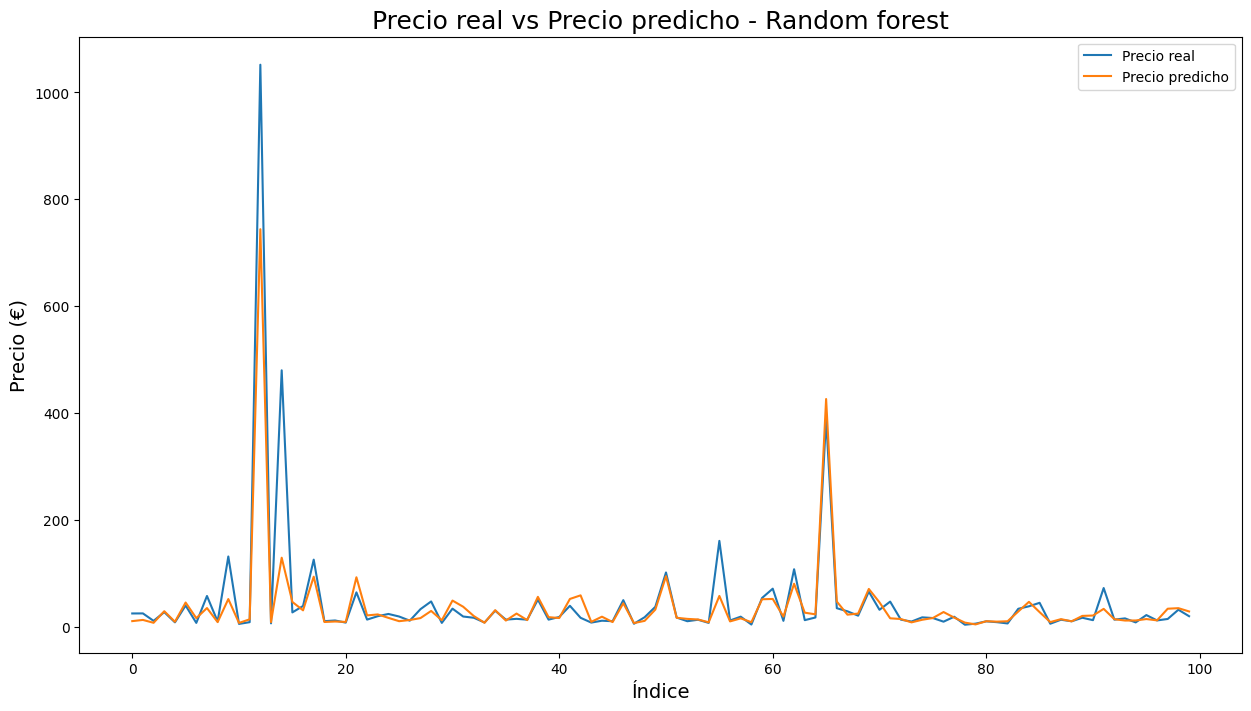

In [227]:
# Configuramos el tamaño del gráfico
plt.figure(figsize=(15, 8))

# Cantidad de registros que se mostrarán en el gráfico
cantidad = 100

# Graficamos los precios reales
plt.plot(
    range(cantidad),
    y_test_original.iloc[:cantidad],
    label="Precio real"
)

# Graficamos los precios predichos por el modelo
plt.plot(
    range(cantidad),
    y_pred[:cantidad],
    label="Precio predicho"
)

# Agregamos título y nombres a los ejes
plt.title("Precio real vs Precio predicho - Random forest", fontsize=18)
plt.xlabel("Índice", fontsize=14)
plt.ylabel("Precio (€)", fontsize=14)

# Mostramos la leyenda
plt.legend()

# Mostramos el gráfico final
plt.show()

* El gráfico compara los precios reales con los precios predichos por el modelo Random Forest Regressor. Se observa que, en la mayoría de los registros, la línea del precio predicho sigue una tendencia similar a la del precio real, especialmente en valores bajos y medios. Esto indica que el modelo logra aproximarse de mejor manera al comportamiento general de los datos.

* Sin embargo, también se evidencian diferencias en algunos valores extremos. Por ejemplo, cuando existen precios reales muy altos, el modelo tiende a subestimarlos, aunque logra acercarse más que los modelos anteriores. En general, el Random Forest presenta un mejor ajuste y una mayor estabilidad predictiva, pero aún mantiene dificultades para predecir correctamente vinos con precios atípicamente elevados.


---



#**7. Dashboard para toma de decisiones**

In [228]:
# Exportamos el dataset limpio para utilizarlo en Power BI o Looker Studio
df_final.to_csv("dataset_vinos_dashboard.csv", index=False)

print("Archivo dataset_vinos_dashboard.csv generado correctamente.")

Archivo dataset_vinos_dashboard.csv generado correctamente.


* Se exportó el dataset limpio en formato CSV para ser utilizado en una herramienta de visualización como Power BI o Looker Studio. Este archivo permite construir un panel interactivo orientado al análisis del precio, rating, país, año y estilo de los vinos.

El dashboard desarrollado en Looker Studio incluye los siguientes indicadores y gráficos:

- Total de vinos analizados.
- Precio promedio de los vinos.
- Rating promedio de los vinos.
- Cantidad total de valoraciones.
- Top 10 países con mayor cantidad de vinos.
- Cantidad de vinos por estilo.
- Precio promedio por década.
- Top 10 países con vinos más caros.

In [229]:
# Importamos las funciones necesarias para mostrar contenido dentro del notebook
from IPython.display import display, Markdown

# Guardamos en una variable el enlace del dashboard creado en Looker Studio
link_looker = "https://datastudio.google.com/reporting/65319531-a005-4a18-8979-30f59ee15cb8"

# Mostramos el enlace del dashboard en formato Markdown para que sea clickeable desde Colab
display(Markdown(f"[Abrir Dashboard en Looker Studio]({link_looker})"))

[Abrir Dashboard en Looker Studio](https://datastudio.google.com/reporting/65319531-a005-4a18-8979-30f59ee15cb8)

* Se incorporó el enlace al dashboard desarrollado en Looker Studio, el cual utiliza el archivo dataset_vinos_dashboard.csv como fuente de datos. Este panel permite visualizar los resultados del análisis realizado en Colab y apoyar la toma de decisiones mediante gráficos interactivos.

# **8. Web Scraping CAV para aumentar/testear el modelo con datos reales**

En esta etapa se realiza un proceso de web scraping sobre la tienda online de CAV, con el objetivo de recolectar datos reales de distintos vinos publicados en la página.

A diferencia de una prueba con un solo producto, este proceso busca obtener múltiples registros desde la web, permitiendo construir un pequeño dataset externo. Este dataset puede utilizarse para complementar el análisis o testear el modelo predictivo con vinos reales que no forman parte del dataset original.

Desde la página se intentan extraer datos como nombre del vino, SKU, viña, cepa, categoría, precio y enlace del producto. Posteriormente, estos datos son transformados para quedar compatibles con las variables utilizadas por el modelo.

https://cav.cl/

In [230]:
# Importamos librerías necesarias para realizar web scraping y procesar datos
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import re
from urllib.parse import urljoin
import time

In [231]:

# URL principal de CAV
url_base = "https://cav.cl/"

# Encabezados para simular una solicitud desde navegador
headers = {
    "User-Agent": "Mozilla/5.0"
}

# Realizamos la solicitud a la página principal
response = requests.get(url_base, headers=headers, timeout=15)

# Validamos el estado de la solicitud
print("Estado de la solicitud:", response.status_code)

# Procesamos el HTML
soup = BeautifulSoup(response.text, "html.parser")

# Buscamos enlaces de productos dentro de la página
links_productos = []

for link in soup.find_all("a", href=True):
    href = link["href"]

    # Filtramos solo enlaces que correspondan a productos de la tienda
    if "/tienda/producto/" in href:
        url_producto = urljoin(url_base, href)
        links_productos.append(url_producto)

# Eliminamos duplicados
links_productos = list(set(links_productos))

print("Cantidad de enlaces de productos encontrados:", len(links_productos))

# Visualizamos algunos enlaces
links_productos[:10]

Estado de la solicitud: 200
Cantidad de enlaces de productos encontrados: 37


['https://cav.cl/tienda/producto/de-martino-cabernet-sauvignon-gran-reserva-2023-35306',
 'https://cav.cl/tienda/producto/pack-hendricks-unusual-garden-32265',
 'https://cav.cl/tienda/producto/los-vascos-cromas-carmenere-gran-reserva-2022-34836',
 'https://cav.cl/tienda/producto/pulltex-bomba-de-vacio-para-vino-negra-27751',
 'https://cav.cl/tienda/producto/lopez-pangue-ensamblaje-tinto-2022-35430',
 'https://cav.cl/tienda/producto/baron-philippe-de-rothschild-mapu-tierra-sagrada-almaule-pais-2024-33687',
 'https://cav.cl/tienda/producto/el-descanso-carmenere-reserva-2022-35435',
 'https://cav.cl/tienda/producto/san-esteban-in-situ-chardonnay-reserva-2024-34215',
 'https://cav.cl/tienda/producto/casa-fevre-quino-brut-nature-750cc-29483',
 'https://cav.cl/tienda/producto/chadwick-cabernet-sauvignon-2022-en-caja-de-madera-33617']

* Se recolectaron enlaces de productos desde la página principal de CAV. Para esto, se filtraron los enlaces que contienen la ruta /tienda/producto/, ya que corresponden a productos reales publicados en la tienda online.

* El código de estado 200 indica que la página principal de CAV respondió correctamente a la solicitud. Desde el HTML obtenido se identificaron enlaces correspondientes a productos reales de la tienda. Estos enlaces serán utilizados posteriormente para ingresar a cada producto y extraer información específica como nombre, SKU, marca, categoría, cepa, puntaje, valoraciones y precio publicado.

#**Extracción de datos desde cada producto**

In [232]:
# Lista para almacenar los productos recolectados
productos_cav = []

# Tipo de cambio referencial CLP a EUR
# Este valor puede actualizarse según el tipo de cambio vigente
tipo_cambio_clp_por_eur = 1050

# Función para convertir pesos chilenos a euros
def convertir_clp_a_eur(precio_clp):
    if precio_clp is None or pd.isna(precio_clp):
        return np.nan

    return round(precio_clp / tipo_cambio_clp_por_eur, 2)

# Recorremos los enlaces encontrados
for url_producto in links_productos:

    try:
        # Solicitamos la página del producto
        response_producto = requests.get(url_producto, headers=headers, timeout=15)

        # Procesamos el HTML del producto
        soup_producto = BeautifulSoup(response_producto.text, "html.parser")

        # Buscamos la sección principal del producto con atributos data-*
        producto = soup_producto.find("section", attrs={"data-sku": True})

        # Si existe la sección, extraemos los datos estructurados
        if producto:
            nombre = producto.get("data-name")
            sku = producto.get("data-sku")
            marca = producto.get("data-brand")
            categoria = producto.get("data-category")
            cepa = producto.get("data-variant")
            precio = producto.get("data-price")

            # Limpiamos el precio en pesos chilenos
            if precio is not None:
                precio = int(re.sub(r"[^0-9]", "", str(precio)))

            # Convertimos el precio desde pesos chilenos a euros
            precio_eur = convertir_clp_a_eur(precio)

            # Guardamos solo productos que tengan nombre y precio
            if nombre and precio:
                productos_cav.append({
                    "Nombre_producto": nombre,
                    "SKU": sku,
                    "Marca": marca,
                    "Categoria": categoria,
                    "Cepa": cepa,
                    "Precio_publicado_CLP": precio,
                    "Precio_publicado_EUR": precio_eur,
                    "URL_producto": url_producto
                })

        # Pausa breve para no saturar la página
        time.sleep(0.5)

    except Exception as e:
        print("Error al procesar:", url_producto)
        print("Detalle:", e)

# Creamos DataFrame
df_cav = pd.DataFrame(productos_cav)

# Eliminamos duplicados
if not df_cav.empty:
    df_cav = df_cav.drop_duplicates(subset=["SKU", "Nombre_producto"])

print("Total de productos recolectados:", len(df_cav))

df_cav.head(10)

Total de productos recolectados: 37


,Nombre_producto,SKU,Marca,Categoria,Cepa,Precio_publicado_CLP,Precio_publicado_EUR,URL_producto
0,De Martino Cabernet Sauvignon Gran Reserva 2023,35306,De Martino,Tinto,Cabernet Sauvignon,10990,10.47,https://cav.cl/tienda/producto/de-martino-cabe...
1,Pack Hendricks Unusual Garden,32265,Hendrick´s,Sin Informacion,Sin Subtipo,27190,25.90,https://cav.cl/tienda/producto/pack-hendricks-...
2,Los Vascos Cromas Carmenere Gran Reserva 2022,34836,Los Vascos,Tinto,Carmenere,12800,12.19,https://cav.cl/tienda/producto/los-vascos-crom...
3,Pulltex Bomba De Vacio Para Vino Negra,27751,Sin Subfamilia,Sin Informacion,Sin Subtipo,14990,14.28,https://cav.cl/tienda/producto/pulltex-bomba-d...
4,Lopez Pangue Ensamblaje Tinto 2022,35430,Lopez Pangue,Ensamblaje Tinto,Sin Informacion,16900,16.10,https://cav.cl/tienda/producto/lopez-pangue-en...
5,Baron Philippe De Rothschild Mapu Tierra Sagra...,33687,Baron Philippe De Rothschild,Tinto,Pais,10990,10.47,https://cav.cl/tienda/producto/baron-philippe-...
6,El Descanso Carmenere Reserva 2022,35435,El Descanso,Tinto,Carmenere,5990,5.70,https://cav.cl/tienda/producto/el-descanso-car...
7,San Esteban In Situ Chardonnay Reserva 2024,34215,In Situ,Blanco,Chardonnay,5990,5.70,https://cav.cl/tienda/producto/san-esteban-in-...
8,Casa Fevre Quino Brut Nature 750cc,29483,William Fevre,Espumoso,Espumoso,26990,25.70,https://cav.cl/tienda/producto/casa-fevre-quin...
9,Chadwick Cabernet Sauvignon 2022 En Caja De Ma...,33617,Chadwick,Tinto,Cabernet Sauvignon,599000,570.48,https://cav.cl/tienda/producto/chadwick-cabern...


* Se extrajeron datos reales desde cada producto de CAV, incluyendo nombre, SKU, marca, categoría, cepa y precio publicado. El precio original fue obtenido en pesos chilenos y posteriormente convertido a euros mediante un tipo de cambio referencial, ya que el modelo predictivo trabaja con precios en euros.

#**Preparación de los datos recolectados**

In [233]:
# Función para extraer el año desde el nombre del producto
def extraer_anio(texto):
    coincidencia = re.search(r"\b(19[0-9]{2}|20[0-9]{2})\b", str(texto))

    if coincidencia:
        return int(coincidencia.group(0))
    else:
        return np.nan


# Función para clasificar el estilo del vino
def clasificar_wine_style(categoria, nombre, cepa):
    texto = (str(categoria) + " " + str(nombre) + " " + str(cepa)).lower()

    if "espumante" in texto or "sparkling" in texto or "champagne" in texto:
        return "Sparkling"
    elif "rosé" in texto or "rose" in texto or "rosado" in texto:
        return "Rose"
    elif "blanco" in texto or "white" in texto or "sauvignon blanc" in texto or "chardonnay" in texto:
        return "White"
    elif "tinto" in texto or "red" in texto or "carmenere" in texto or "cabernet" in texto or "merlot" in texto or "syrah" in texto:
        return "Red"
    else:
        return "Red"


# Creamos variable Year desde el nombre del producto
df_cav["Year"] = df_cav["Nombre_producto"].apply(extraer_anio)

# Si no se encuentra año, se reemplaza por la mediana del dataset original
df_cav["Year"] = df_cav["Year"].fillna(df_final["Year"].median())

# Creamos variable WineStyle
df_cav["WineStyle"] = df_cav.apply(
    lambda fila: clasificar_wine_style(
        fila["Categoria"],
        fila["Nombre_producto"],
        fila["Cepa"]
    ),
    axis=1
)

# Asignamos país Chile como referencia, ya que CAV es una tienda chilena y muchos productos corresponden al mercado nacional
df_cav["Country"] = "Chile"

# Como CAV no entrega Rating ni NumberOfRatings en el mismo formato del dataset original,
# se completan con la mediana del dataset original
df_cav["Rating"] = df_final["Rating"].median()
df_cav["NumberOfRatings"] = df_final["NumberOfRatings"].median()

df_cav.head(10)

,Nombre_producto,SKU,Marca,Categoria,Cepa,Precio_publicado_CLP,Precio_publicado_EUR,URL_producto,Year,WineStyle,Country,Rating,NumberOfRatings
0,De Martino Cabernet Sauvignon Gran Reserva 2023,35306,De Martino,Tinto,Cabernet Sauvignon,10990,10.47,https://cav.cl/tienda/producto/de-martino-cabe...,2023.0,Red,Chile,3.9,129.0
1,Pack Hendricks Unusual Garden,32265,Hendrick´s,Sin Informacion,Sin Subtipo,27190,25.90,https://cav.cl/tienda/producto/pack-hendricks-...,2016.0,Red,Chile,3.9,129.0
2,Los Vascos Cromas Carmenere Gran Reserva 2022,34836,Los Vascos,Tinto,Carmenere,12800,12.19,https://cav.cl/tienda/producto/los-vascos-crom...,2022.0,Red,Chile,3.9,129.0
3,Pulltex Bomba De Vacio Para Vino Negra,27751,Sin Subfamilia,Sin Informacion,Sin Subtipo,14990,14.28,https://cav.cl/tienda/producto/pulltex-bomba-d...,2016.0,Red,Chile,3.9,129.0
4,Lopez Pangue Ensamblaje Tinto 2022,35430,Lopez Pangue,Ensamblaje Tinto,Sin Informacion,16900,16.10,https://cav.cl/tienda/producto/lopez-pangue-en...,2022.0,Red,Chile,3.9,129.0
5,Baron Philippe De Rothschild Mapu Tierra Sagra...,33687,Baron Philippe De Rothschild,Tinto,Pais,10990,10.47,https://cav.cl/tienda/producto/baron-philippe-...,2024.0,Red,Chile,3.9,129.0
6,El Descanso Carmenere Reserva 2022,35435,El Descanso,Tinto,Carmenere,5990,5.70,https://cav.cl/tienda/producto/el-descanso-car...,2022.0,Red,Chile,3.9,129.0
7,San Esteban In Situ Chardonnay Reserva 2024,34215,In Situ,Blanco,Chardonnay,5990,5.70,https://cav.cl/tienda/producto/san-esteban-in-...,2024.0,White,Chile,3.9,129.0
8,Casa Fevre Quino Brut Nature 750cc,29483,William Fevre,Espumoso,Espumoso,26990,25.70,https://cav.cl/tienda/producto/casa-fevre-quin...,2016.0,Red,Chile,3.9,129.0
9,Chadwick Cabernet Sauvignon 2022 En Caja De Ma...,33617,Chadwick,Tinto,Cabernet Sauvignon,599000,570.48,https://cav.cl/tienda/producto/chadwick-cabern...,2022.0,Red,Chile,3.9,129.0


* Se validó el dataset recolectado desde CAV, revisando la cantidad de productos obtenidos, la estructura de columnas y una muestra de los registros principales. Esta validación permite confirmar que el proceso de web scraping generó datos reales y utilizables para testear el modelo.

#**Dataset externo preparado**

In [234]:
# Seleccionamos las columnas relevantes del dataset externo
df_cav_preparado = df_cav[[
    "Nombre_producto",
    "SKU",
    "Marca",
    "Categoria",
    "Cepa",
    "Precio_publicado_CLP",
    "Precio_publicado_EUR",
    "URL_producto",
    "Rating",
    "NumberOfRatings",
    "Year",
    "Country",
    "WineStyle"
]].copy()

df_cav_preparado.head(10)

,Nombre_producto,SKU,Marca,Categoria,Cepa,Precio_publicado_CLP,Precio_publicado_EUR,URL_producto,Rating,NumberOfRatings,Year,Country,WineStyle
0,De Martino Cabernet Sauvignon Gran Reserva 2023,35306,De Martino,Tinto,Cabernet Sauvignon,10990,10.47,https://cav.cl/tienda/producto/de-martino-cabe...,3.9,129.0,2023.0,Chile,Red
1,Pack Hendricks Unusual Garden,32265,Hendrick´s,Sin Informacion,Sin Subtipo,27190,25.90,https://cav.cl/tienda/producto/pack-hendricks-...,3.9,129.0,2016.0,Chile,Red
2,Los Vascos Cromas Carmenere Gran Reserva 2022,34836,Los Vascos,Tinto,Carmenere,12800,12.19,https://cav.cl/tienda/producto/los-vascos-crom...,3.9,129.0,2022.0,Chile,Red
3,Pulltex Bomba De Vacio Para Vino Negra,27751,Sin Subfamilia,Sin Informacion,Sin Subtipo,14990,14.28,https://cav.cl/tienda/producto/pulltex-bomba-d...,3.9,129.0,2016.0,Chile,Red
4,Lopez Pangue Ensamblaje Tinto 2022,35430,Lopez Pangue,Ensamblaje Tinto,Sin Informacion,16900,16.10,https://cav.cl/tienda/producto/lopez-pangue-en...,3.9,129.0,2022.0,Chile,Red
5,Baron Philippe De Rothschild Mapu Tierra Sagra...,33687,Baron Philippe De Rothschild,Tinto,Pais,10990,10.47,https://cav.cl/tienda/producto/baron-philippe-...,3.9,129.0,2024.0,Chile,Red
6,El Descanso Carmenere Reserva 2022,35435,El Descanso,Tinto,Carmenere,5990,5.70,https://cav.cl/tienda/producto/el-descanso-car...,3.9,129.0,2022.0,Chile,Red
7,San Esteban In Situ Chardonnay Reserva 2024,34215,In Situ,Blanco,Chardonnay,5990,5.70,https://cav.cl/tienda/producto/san-esteban-in-...,3.9,129.0,2024.0,Chile,White
8,Casa Fevre Quino Brut Nature 750cc,29483,William Fevre,Espumoso,Espumoso,26990,25.70,https://cav.cl/tienda/producto/casa-fevre-quin...,3.9,129.0,2016.0,Chile,Red
9,Chadwick Cabernet Sauvignon 2022 En Caja De Ma...,33617,Chadwick,Tinto,Cabernet Sauvignon,599000,570.48,https://cav.cl/tienda/producto/chadwick-cabern...,3.9,129.0,2022.0,Chile,Red


* Se creó un dataset externo preparado con las variables más relevantes obtenidas desde CAV. Se mantiene el precio original en pesos chilenos y también su conversión a euros, permitiendo comparar el precio publicado con la predicción del modelo.

#**Preparación de los datos CAV para el modelo**

In [235]:
# Seleccionamos las variables utilizadas por el modelo
datos_cav_modelo = df_cav_preparado[[
    "Rating",
    "NumberOfRatings",
    "Year",
    "Country",
    "WineStyle"
]].copy()

# Aplicamos One-Hot Encoding
datos_cav_encoded = pd.get_dummies(
    datos_cav_modelo,
    columns=["Country", "WineStyle"],
    drop_first=True
)

# Alineamos las columnas con las columnas usadas en el entrenamiento
datos_cav_encoded = datos_cav_encoded.reindex(
    columns=X_train.columns,
    fill_value=0
)

datos_cav_encoded.head()

,Rating,NumberOfRatings,Year,Country_Argentina,Country_Australia,Country_Austria,Country_Brazil,Country_Bulgaria,Country_Canada,Country_Chile,...,Country_Spain,Country_Switzerland,Country_Turkey,Country_United Kingdom,Country_United States,Country_Uruguay,WineStyle_red,WineStyle_rose,WineStyle_sparkling,WineStyle_white
0,3.9,129.0,2023.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,3.9,129.0,2016.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3.9,129.0,2022.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3.9,129.0,2016.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,3.9,129.0,2022.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


* Los datos recolectados desde CAV fueron transformados para ser compatibles con el modelo predictivo. Para ello, se aplicó One-Hot Encoding a las variables categóricas Country y WineStyle. Posteriormente, las columnas fueron alineadas con la estructura utilizada durante el entrenamiento, permitiendo que el modelo pueda recibir estos datos externos sin errores de formato.

#**Predicción con datos reales recolectados desde CAV**

In [236]:
# Definimos el modelo final si aún no existe
try:
    modelo_final
except NameError:
    modelo_final = rf

# Realizamos predicciones en escala logarítmica
predicciones_cav_log = modelo_final.predict(datos_cav_encoded)

# Convertimos las predicciones a escala original
predicciones_cav_eur = np.expm1(predicciones_cav_log)

# Evitamos posibles valores negativos
predicciones_cav_eur = np.maximum(predicciones_cav_eur, 0)

# Agregamos la predicción al dataset externo
df_cav_preparado["Precio_estimado_modelo_EUR"] = predicciones_cav_eur

# Calculamos la diferencia entre el precio publicado convertido a euros y el precio estimado por el modelo
df_cav_preparado["Diferencia_EUR"] = abs(
    df_cav_preparado["Precio_publicado_EUR"] - df_cav_preparado["Precio_estimado_modelo_EUR"]
)

# Visualizamos los resultados principales
df_cav_preparado[[
    "Nombre_producto",
    "Rating",
    "NumberOfRatings",
    "Year",
    "Country",
    "WineStyle",
    "Precio_publicado_CLP",
    "Precio_publicado_EUR",
    "Precio_estimado_modelo_EUR",
    "Diferencia_EUR"
]].head(10)

,Nombre_producto,Rating,NumberOfRatings,Year,Country,WineStyle,Precio_publicado_CLP,Precio_publicado_EUR,Precio_estimado_modelo_EUR,Diferencia_EUR
0,De Martino Cabernet Sauvignon Gran Reserva 2023,3.9,129.0,2023.0,Chile,Red,10990,10.47,11.078571,0.608571
1,Pack Hendricks Unusual Garden,3.9,129.0,2016.0,Chile,Red,27190,25.90,17.043890,8.856110
2,Los Vascos Cromas Carmenere Gran Reserva 2022,3.9,129.0,2022.0,Chile,Red,12800,12.19,11.078571,1.111429
3,Pulltex Bomba De Vacio Para Vino Negra,3.9,129.0,2016.0,Chile,Red,14990,14.28,17.043890,2.763890
4,Lopez Pangue Ensamblaje Tinto 2022,3.9,129.0,2022.0,Chile,Red,16900,16.10,11.078571,5.021429
5,Baron Philippe De Rothschild Mapu Tierra Sagra...,3.9,129.0,2024.0,Chile,Red,10990,10.47,11.078571,0.608571
6,El Descanso Carmenere Reserva 2022,3.9,129.0,2022.0,Chile,Red,5990,5.70,11.078571,5.378571
7,San Esteban In Situ Chardonnay Reserva 2024,3.9,129.0,2024.0,Chile,White,5990,5.70,11.078571,5.378571
8,Casa Fevre Quino Brut Nature 750cc,3.9,129.0,2016.0,Chile,Red,26990,25.70,17.043890,8.656110
9,Chadwick Cabernet Sauvignon 2022 En Caja De Ma...,3.9,129.0,2022.0,Chile,Red,599000,570.48,11.078571,559.401429


* Se utilizó el modelo Random Forest Regressor para estimar el precio de los vinos recolectados desde CAV. Como los precios publicados fueron obtenidos en pesos chilenos, estos fueron convertidos a euros para mantener consistencia con la escala del dataset original y permitir la comparación con el precio estimado por el modelo.

In [237]:
# Exportamos el dataset externo recolectado desde CAV con las predicciones del modelo
df_cav_preparado.to_csv("dataset_cav_scraping_predicciones.csv", index=False)

print("Archivo dataset_cav_scraping_predicciones.csv generado correctamente.")

Archivo dataset_cav_scraping_predicciones.csv generado correctamente.


* Se exportó el archivo dataset_cav_scraping_predicciones.csv, el cual contiene vinos reales recolectados desde la tienda online de CAV junto con las variables preparadas y el precio estimado por el modelo. Este archivo funciona como evidencia del uso de web scraping para testear el modelo con datos reales.

Inicialmente se intentó realizar web scraping automático desde Vivino, debido a que el dataset original del proyecto proviene de esa plataforma. Sin embargo, las solicitudes al endpoint de exploración de Vivino retornaron código 403, lo que indica que la plataforma bloquea el acceso automatizado desde el entorno de Colab.

Por esta razón, se utilizó como fuente externa alternativa la tienda online de CAV, la cual permite recolectar datos reales de vinos mediante scraping directo. Esta fuente entrega información útil como nombre del producto, cepa, cosecha, tipo de vino, precio publicado, puntaje y cantidad de valoraciones, permitiendo testear el modelo con datos reales externos al dataset original.

In [238]:
#------------------------------------------------------------------------------------------------------------------------------

# **8. Web Scraping VIVINO para aumentar/testear el modelo con datos reales**

En esta etapa se realiza un proceso de web scraping desde Vivino, plataforma relacionada directamente con el dataset original utilizado en el proyecto. El objetivo es recolectar productos reales desde la página web, preparar sus variables y utilizarlas para testear el modelo predictivo con datos externos.

El proceso consiste en ingresar a Vivino, recolectar automáticamente enlaces de productos, acceder a cada página de vino y extraer información como nombre, rating, cantidad de valoraciones, año, país, estilo de vino y precio publicado cuando esté disponible.

Posteriormente, los datos recolectados son transformados para mantener compatibilidad con la estructura utilizada durante el entrenamiento del modelo de Machine Learning.

https://www.vivino.com/es/

In [239]:
# Importamos librerías necesarias para realizar web scraping y procesamiento de datos
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import re
import time
from urllib.parse import urljoin

In [240]:
# Recolección automática de enlaces de vinos desde Vivino
# URL base de Vivino
url_base_vivino = "https://www.vivino.com/es/"

# Encabezados para simular una solicitud desde navegador
headers_vivino = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                  "(KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Accept-Language": "es-CL,es;q=0.9,en;q=0.8",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Referer": "https://www.vivino.com/es/"
}

# Solicitamos la página principal de Vivino
response = requests.get(url_base_vivino, headers=headers_vivino, timeout=20)

# Mostramos el estado de la solicitud
print("Estado de la solicitud:", response.status_code)

# Procesamos el HTML obtenido
soup = BeautifulSoup(response.text, "html.parser")

# Lista para guardar enlaces de productos encontrados
links_vivino = []

# Recorremos todos los enlaces disponibles en la página
for link in soup.find_all("a", href=True):
    href = link["href"]

    # En Vivino, las páginas de vinos suelen contener la ruta /w/
    if "/w/" in href:
        url_producto = urljoin("https://www.vivino.com", href)
        links_vivino.append(url_producto)

# Eliminamos enlaces duplicados
links_vivino = list(set(links_vivino))

# Mostramos la cantidad de enlaces encontrados
print("Cantidad de enlaces de vinos encontrados:", len(links_vivino))

# Visualizamos algunos enlaces encontrados
links_vivino[:10]

Estado de la solicitud: 403
Cantidad de enlaces de vinos encontrados: 0


[]

* Se realizó una solicitud a la página principal de Vivino y se procesó su contenido HTML. A partir de este contenido, se identificaron enlaces que contienen la ruta /w/, la cual corresponde a páginas de productos de vino dentro de Vivino. Estos enlaces serán utilizados para ingresar a cada producto y extraer información específica.

#**Funciones auxiliares para extracción y transformación**

In [241]:
# Tipo de cambio referencial USD a EUR
# Se utiliza porque Vivino puede entregar precios en USD dentro del HTML
tipo_cambio_usd_a_eur = 0.93

# Tipo de cambio referencial CLP a EUR
# Se mantiene por si alguna página entrega precio en pesos chilenos
tipo_cambio_clp_por_eur = 1050


# Función para extraer el primer patrón encontrado mediante expresiones regulares
def extraer_regex(patron, texto, grupo=1):
    coincidencia = re.search(patron, texto, re.IGNORECASE)

    if coincidencia:
        return coincidencia.group(grupo)

    return np.nan


# Función para limpiar valores numéricos desde texto
def limpiar_numero(texto):
    if texto is None or pd.isna(texto):
        return np.nan

    texto = str(texto).replace(",", ".")
    coincidencia = re.search(r"\d+(\.\d+)?", texto)

    if coincidencia:
        return float(coincidencia.group(0))

    return np.nan


# Función para extraer año desde texto o URL
def extraer_anio(texto):
    coincidencia = re.search(r"\b(19[0-9]{2}|20[0-9]{2})\b", str(texto))

    if coincidencia:
        return int(coincidencia.group(0))

    return np.nan


# Función para convertir precio en USD a EUR
def convertir_usd_a_eur(precio_usd):
    if precio_usd is None or pd.isna(precio_usd):
        return np.nan

    return round(float(precio_usd) * tipo_cambio_usd_a_eur, 2)


# Función para convertir precio en CLP a EUR
def convertir_clp_a_eur(precio_clp):
    if precio_clp is None or pd.isna(precio_clp):
        return np.nan

    return round(float(precio_clp) / tipo_cambio_clp_por_eur, 2)


# Función para clasificar el estilo del vino según texto disponible
def clasificar_wine_style(texto):
    texto = str(texto).lower()

    if "sparkling" in texto or "espumoso" in texto or "espumante" in texto or "champagne" in texto:
        return "Sparkling"
    elif "rosé" in texto or "rose" in texto or "rosado" in texto:
        return "Rose"
    elif "white" in texto or "blanco" in texto or "riesling" in texto or "chardonnay" in texto or "sauvignon blanc" in texto:
        return "White"
    elif "red" in texto or "tinto" in texto or "cabernet" in texto or "merlot" in texto or "carmenere" in texto or "syrah" in texto:
        return "Red"
    else:
        return "Red"


# Función para clasificar el estilo según el código wine_type de Vivino
def clasificar_wine_type_id(wine_type_id):
    mapa_tipos = {
        "1": "Red",
        "2": "White",
        "3": "Sparkling",
        "4": "Rose"
    }

    return mapa_tipos.get(str(wine_type_id), np.nan)


# Función para estimar país desde el texto disponible
def estimar_pais(texto):
    texto = str(texto).lower()

    if "chile" in texto:
        return "Chile"
    elif "argentina" in texto:
        return "Argentina"
    elif "france" in texto or "francia" in texto:
        return "France"
    elif "spain" in texto or "españa" in texto:
        return "Spain"
    elif "italy" in texto or "italia" in texto:
        return "Italy"
    elif "germany" in texto or "alemania" in texto:
        return "Germany"
    elif "portugal" in texto:
        return "Portugal"
    elif "australia" in texto:
        return "Australia"
    elif "united states" in texto or "estados unidos" in texto:
        return "United States"
    else:
        return np.nan

* Se definieron funciones auxiliares para extraer y transformar los datos recolectados desde Vivino. Estas funciones permiten limpiar números, extraer años, convertir precios a euros, clasificar el estilo del vino y estimar el país cuando la información se encuentra disponible en el HTML.

#**Extracción de datos desde cada producto Vivino**




In [242]:
# Lista para almacenar los productos recolectados desde Vivino
productos_vivino = []

# Cantidad máxima de productos a procesar para evitar saturar el sitio
max_productos = 50

# Recorremos los enlaces encontrados
for url_producto in links_vivino[:max_productos]:

    try:
        # Solicitamos la página de cada producto
        response_producto = requests.get(url_producto, headers=headers_vivino, timeout=20)

        # Mostramos estado de cada solicitud
        print("URL:", url_producto)
        print("Estado:", response_producto.status_code)

        # Si la página no responde correctamente, se omite
        if response_producto.status_code != 200:
            print("-" * 50)
            continue

        # Guardamos el HTML como texto
        html = response_producto.text

        # Procesamos el HTML con BeautifulSoup
        soup_producto = BeautifulSoup(html, "html.parser")

        # Extraemos título de la página
        titulo = soup_producto.title.get_text(strip=True) if soup_producto.title else np.nan

        # Extraemos descripción meta
        meta_desc = soup_producto.find("meta", attrs={"name": "description"})
        descripcion = meta_desc.get("content") if meta_desc else ""

        # Limpiamos el nombre del producto desde el título
        nombre_producto = str(titulo).replace("| Vivino Español", "").replace("| Vivino", "").strip()

        # Extraemos año desde la URL, título o descripción
        year = extraer_anio(url_producto)

        if pd.isna(year):
            year = extraer_anio(nombre_producto)

        if pd.isna(year):
            year = extraer_anio(descripcion)

        # Extraemos vintage_id desde el HTML si aparece
        vintage_id = extraer_regex(r'"vintage_id":\s*(\d+)', html)

        # Extraemos wine_style_id desde el HTML si aparece
        wine_style_id = extraer_regex(r'"wine_style_id":\s*(\d+)', html)

        # Extraemos wine_type desde scripts de publicidad si aparece
        wine_type_id = extraer_regex(r'setTargeting\("wine_type",\s*"(\d+)"\)', html)

        # Extraemos rating promedio
        rating = extraer_regex(r'"ratings_average":\s*([\d\.]+)', html)

        if pd.isna(rating):
            rating = extraer_regex(r'"average_rating":\s*([\d\.]+)', html)

        rating = limpiar_numero(rating)

        # Extraemos cantidad de valoraciones
        number_of_ratings = extraer_regex(r'"ratings_count":\s*(\d+)', html)

        if pd.isna(number_of_ratings):
            number_of_ratings = extraer_regex(r'"reviews_count":\s*(\d+)', html)

        number_of_ratings = limpiar_numero(number_of_ratings)

        # Extraemos precio default en USD si aparece
        precio_usd = extraer_regex(r'setTargeting\("default_price_usd",\s*"([\d\.]+)"\)', html)
        precio_usd = limpiar_numero(precio_usd)

        # Extraemos posible precio CLP si aparece dentro del HTML
        precio_clp = extraer_regex(r'"amount":\s*(\d+).*?"currency":\s*\{"code":"CLP"', html)
        precio_clp = limpiar_numero(precio_clp)

        # Convertimos precio a EUR
        if not pd.isna(precio_usd):
            precio_publicado_eur = convertir_usd_a_eur(precio_usd)
        elif not pd.isna(precio_clp):
            precio_publicado_eur = convertir_clp_a_eur(precio_clp)
        else:
            precio_publicado_eur = np.nan

        # Estimamos país desde texto disponible
        texto_base = nombre_producto + " " + descripcion + " " + html[:8000]
        country = estimar_pais(texto_base)

        # Clasificamos estilo del vino
        wine_style = clasificar_wine_type_id(wine_type_id)

        if pd.isna(wine_style):
            wine_style = clasificar_wine_style(texto_base)

        # Guardamos producto recolectado
        productos_vivino.append({
            "Nombre_producto": nombre_producto,
            "Vintage_ID": vintage_id,
            "Wine_Style_ID": wine_style_id,
            "Wine_Type_ID": wine_type_id,
            "Rating": rating,
            "NumberOfRatings": number_of_ratings,
            "Year": year,
            "Country": country,
            "WineStyle": wine_style,
            "Precio_publicado_USD": precio_usd,
            "Precio_publicado_CLP": precio_clp,
            "Precio_publicado_EUR": precio_publicado_eur,
            "Descripcion": descripcion,
            "URL_producto": url_producto
        })

        print("Producto recolectado:", nombre_producto)
        print("-" * 50)

        # Pausa breve para no saturar Vivino
        time.sleep(1)

    except Exception as e:
        print("Error al procesar:", url_producto)
        print("Detalle:", e)
        print("-" * 50)

# Creamos DataFrame con los productos recolectados
df_vivino = pd.DataFrame(productos_vivino)

# Eliminamos duplicados
if not df_vivino.empty:
    df_vivino = df_vivino.drop_duplicates(subset=["Nombre_producto", "URL_producto"])

# Mostramos cantidad total recolectada
print("Total de productos recolectados desde Vivino:", len(df_vivino))

# Visualizamos los primeros registros
df_vivino.head(10)

Total de productos recolectados desde Vivino: 0


""


* Se ingresó a cada enlace de producto recolectado desde Vivino y se extrajo información disponible en el HTML. Entre las variables obtenidas se encuentran nombre del producto, rating, cantidad de valoraciones, año, país, estilo de vino y precio publicado. Los precios fueron convertidos a euros para mantener compatibilidad con la escala utilizada en el dataset original.

#**Validación de los datos recolectados desde Vivino**

In [243]:
# Revisamos la cantidad de productos recolectados
print("Cantidad de productos recolectados:", len(df_vivino))

# Revisamos la estructura del DataFrame
df_vivino.info()

# Visualizamos las columnas principales
df_vivino[[
    "Nombre_producto",
    "Rating",
    "NumberOfRatings",
    "Year",
    "Country",
    "WineStyle",
    "Precio_publicado_USD",
    "Precio_publicado_CLP",
    "Precio_publicado_EUR"
]].head(10)

Cantidad de productos recolectados: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Empty DataFrame


KeyError: "None of [Index(['Nombre_producto', 'Rating', 'NumberOfRatings', 'Year', 'Country',\n       'WineStyle', 'Precio_publicado_USD', 'Precio_publicado_CLP',\n       'Precio_publicado_EUR'],\n      dtype='object')] are in the [columns]"

* Se validó el dataset recolectado desde Vivino revisando la cantidad de registros obtenidos, la estructura de columnas y una muestra de las variables principales. Esta validación permite confirmar que los datos fueron recolectados correctamente antes de prepararlos para el modelo.

#**Tratamiento de valores faltantes**

In [ ]:
# Completamos Rating con la mediana del dataset original si no fue detectado en Vivino
df_vivino["Rating"] = df_vivino["Rating"].fillna(df_final["Rating"].median())

# Completamos NumberOfRatings con la mediana del dataset original si no fue detectado
df_vivino["NumberOfRatings"] = df_vivino["NumberOfRatings"].fillna(df_final["NumberOfRatings"].median())

# Completamos Year con la mediana del dataset original si no fue detectado
df_vivino["Year"] = df_vivino["Year"].fillna(df_final["Year"].median())

# Completamos Country si no fue detectado
df_vivino["Country"] = df_vivino["Country"].fillna("Chile")

# Completamos WineStyle si no fue detectado
df_vivino["WineStyle"] = df_vivino["WineStyle"].fillna("Red")

# Revisamos valores nulos en variables utilizadas por el modelo
df_vivino[[
    "Rating",
    "NumberOfRatings",
    "Year",
    "Country",
    "WineStyle"
]].isnull().sum()

* Se trataron valores faltantes en las variables requeridas por el modelo. En caso de que Vivino no entregue directamente rating, cantidad de valoraciones, año, país o estilo de vino, se completan los valores utilizando la mediana del dataset original o una categoría por defecto. Esto permite mantener la compatibilidad con el modelo sin eliminar registros recolectados.

#**Dataset externo preparado desde Vivino**

In [ ]:
# Seleccionamos columnas relevantes del dataset externo
df_vivino_preparado = df_vivino[[
    "Nombre_producto",
    "Rating",
    "NumberOfRatings",
    "Year",
    "Country",
    "WineStyle",
    "Precio_publicado_USD",
    "Precio_publicado_CLP",
    "Precio_publicado_EUR",
    "URL_producto"
]].copy()

# Visualizamos el dataset preparado
df_vivino_preparado.head(10)

* Se construyó un dataset externo preparado a partir de los vinos recolectados desde Vivino. Este dataset contiene las variables principales requeridas para probar el modelo predictivo con datos reales externos.

#**Preparación de los datos Vivino para el modelo**

In [ ]:
# Seleccionamos las variables utilizadas por el modelo predictivo
datos_vivino_modelo = df_vivino_preparado[[
    "Rating",
    "NumberOfRatings",
    "Year",
    "Country",
    "WineStyle"
]].copy()

# Aplicamos One-Hot Encoding a las variables categóricas
datos_vivino_encoded = pd.get_dummies(
    datos_vivino_modelo,
    columns=["Country", "WineStyle"],
    drop_first=True
)

# Definimos el modelo final si aún no existe
try:
    modelo_final
except NameError:
    modelo_final = rf

# Obtenemos las columnas utilizadas durante el entrenamiento del modelo
if "X_train" in globals():
    columnas_modelo = X_train.columns
elif "X" in globals():
    columnas_modelo = X.columns
elif hasattr(modelo_final, "feature_names_in_"):
    columnas_modelo = modelo_final.feature_names_in_
else:
    columnas_modelo = df_final.drop(
        columns=["Price", "Price_log"],
        errors="ignore"
    ).columns

# Alineamos las columnas del dataset Vivino con las columnas usadas durante el entrenamiento
datos_vivino_encoded = datos_vivino_encoded.reindex(
    columns=columnas_modelo,
    fill_value=0
)

# Visualizamos la estructura final
datos_vivino_encoded.head()

* Los datos recolectados desde Vivino fueron transformados para ser compatibles con el modelo predictivo. Para ello, se aplicó One-Hot Encoding a las variables categóricas Country y WineStyle. Luego, las columnas fueron alineadas con la estructura utilizada durante el entrenamiento del modelo.

#**Predicción con datos reales recolectados desde VIVINO**

In [ ]:
# Realizamos predicciones en escala logarítmica
predicciones_vivino_log = modelo_final.predict(datos_vivino_encoded)

# Convertimos las predicciones desde escala logarítmica a escala original
predicciones_vivino_eur = np.expm1(predicciones_vivino_log)

# Evitamos posibles valores negativos
predicciones_vivino_eur = np.maximum(predicciones_vivino_eur, 0)

# Agregamos la predicción al dataset externo preparado
df_vivino_preparado["Precio_estimado_modelo_EUR"] = predicciones_vivino_eur

# Calculamos la diferencia entre precio publicado y precio estimado cuando exista precio publicado
df_vivino_preparado["Diferencia_EUR"] = abs(
    df_vivino_preparado["Precio_publicado_EUR"] - df_vivino_preparado["Precio_estimado_modelo_EUR"]
)

# Visualizamos resultados principales
df_vivino_preparado[[
    "Nombre_producto",
    "Rating",
    "NumberOfRatings",
    "Year",
    "Country",
    "WineStyle",
    "Precio_publicado_EUR",
    "Precio_estimado_modelo_EUR",
    "Diferencia_EUR"
]].head(10)

* Se utilizó el modelo Random Forest Regressor para estimar el precio de los vinos recolectados desde Vivino. Las predicciones fueron convertidas desde escala logarítmica a escala original, permitiendo interpretar el resultado en euros y compararlo con el precio publicado cuando este se encuentra disponible.

In [ ]:
# Exportamos el dataset externo recolectado desde Vivino con sus predicciones
df_vivino_preparado.to_csv("dataset_vivino_scraping_predicciones.csv", index=False)

print("Archivo dataset_vivino_scraping_predicciones2.csv generado correctamente.")

* Se exportó el archivo dataset_vivino_scraping_predicciones.csv, el cual contiene vinos reales recolectados desde Vivino junto con sus variables preparadas, precio publicado convertido a euros y precio estimado por el modelo. Este archivo funciona como evidencia del uso de web scraping para testear el modelo con datos reales.

In [ ]:
#---------------------------------------------------------------------------------

#**9. Integración de su modelo en archivo .PKL en algún flujo de negocio (habilitar algún API con Flask, integrarlo con un formulario web, app android, etc)**

#**10. Set de datos de prueba**

#**11. Modelo k-means en todos los proyectos.**

Las variables seleccionadas son:

- Price: precio del vino.
- Rating: calificación promedio del vino.
- NumberOfRatings: cantidad de valoraciones recibidas.
- Year: año del vino.

In [ ]:
# Seleccionamos las variables numéricas para aplicar K-Means
variables_kmeans = df_final[["Price", "Rating", "NumberOfRatings", "Year"]].copy()

# Eliminamos posibles valores nulos para evitar errores en el modelo
variables_kmeans = variables_kmeans.dropna()

# Visualizamos las primeras filas
variables_kmeans.head()

* Se seleccionaron las variables Price, Rating, NumberOfRatings y Year para aplicar el modelo K-Means. Estas variables permiten agrupar los vinos según su valor comercial, calidad percibida, popularidad y año de producción.

In [ ]:
# Importamos StandardScaler para escalar las variables
from sklearn.preprocessing import StandardScaler

# Creamos el escalador
scaler_kmeans = StandardScaler()

# Aplicamos el escalamiento
variables_kmeans_escaladas = scaler_kmeans.fit_transform(variables_kmeans)

# Visualizamos el resultado escalado
variables_kmeans_escaladas[:5]

* Se aplicó StandardScaler para estandarizar las variables utilizadas en K-Means. De esta forma, todas las variables quedan en una escala comparable y el modelo puede calcular las distancias de manera más equilibrada.

In [ ]:
# Importamos KMeans
from sklearn.cluster import KMeans

# Lista para guardar los valores de inercia
inercias = []

# Probamos distintos valores de K
valores_k = range(1, 11)

for k in valores_k:
    kmeans = KMeans(
        n_clusters=k,
        random_state=100,
        n_init=10
    )
    kmeans.fit(variables_kmeans_escaladas)
    inercias.append(kmeans.inertia_)

# Graficamos el método del codo
plt.figure(figsize=(10, 6))
plt.plot(valores_k, inercias, marker="o")
plt.title("Método del Codo para K-Means", fontsize=16)
plt.xlabel("Número de clusters K", fontsize=12)
plt.ylabel("Inercia", fontsize=12)
plt.show()

* El método del codo permite observar en qué punto la disminución de la inercia comienza a ser menos pronunciada. A partir de este análisis, se selecciona una cantidad de clusters adecuada para segmentar los vinos sin generar una división excesiva de los datos.

In [ ]:
# Creamos el modelo K-Means con 4 clusters
kmeans_final = KMeans(
    n_clusters=4,
    random_state=100,
    n_init=10
)

# Entrenamos el modelo y asignamos cada vino a un cluster
clusters = kmeans_final.fit_predict(variables_kmeans_escaladas)

# Agregamos los clusters al dataframe utilizado para K-Means
variables_kmeans["Cluster"] = clusters

# Visualizamos las primeras filas con el cluster asignado
variables_kmeans.head()

* Se aplicó el modelo K-Means con 4 clusters, asignando cada vino a un grupo según sus características numéricas. Esta segmentación permite analizar perfiles de vinos similares y apoyar decisiones relacionadas con precios, posicionamiento y estrategias comerciales.

In [ ]:
# Calculamos el promedio de las variables por cada cluster
analisis_clusters = variables_kmeans.groupby("Cluster")[["Price", "Rating", "NumberOfRatings", "Year"]].mean()

# Mostramos el análisis de clusters
analisis_clusters

* El análisis de clusters permite observar las características promedio de cada grupo de vinos. Por ejemplo, algunos clusters pueden representar vinos de menor precio y calificación media, mientras que otros pueden agrupar vinos de mayor precio, mayor rating o mayor cantidad de valoraciones.

Esta información es útil para la toma de decisiones, ya que permite identificar segmentos comerciales dentro del mercado de vinos.

In [ ]:
# Gráfico de dispersión de los clusters
plt.figure(figsize=(10, 6))

plt.scatter(
    variables_kmeans["Rating"],
    variables_kmeans["Price"],
    c=variables_kmeans["Cluster"],
    alpha=0.6
)

plt.title("Segmentación de Vinos con K-Means", fontsize=16)
plt.xlabel("Rating", fontsize=12)
plt.ylabel("Price (€)", fontsize=12)
plt.show()

* El gráfico permite visualizar la segmentación de los vinos según su rating y precio. Cada grupo representa un conjunto de vinos con características similares, lo que facilita la identificación de patrones comerciales y posibles categorías de mercado.

In [ ]:
# Configuramos el tamaño del gráfico
plt.figure(figsize=(15, 8))

# Cantidad de registros que se mostrarán en el gráfico
cantidad = 100

# Graficamos los precios reales
plt.plot(
    range(cantidad),
    y_test_original.iloc[:cantidad],
    label="Precio real"
)

# Graficamos los precios predichos por el modelo
plt.plot(
    range(cantidad),
    y_pred[:cantidad],
    label="Precio predicho"
)

# Agregamos título y nombres a los ejes
plt.title("Precio real vs Precio predicho - Random forest", fontsize=18)
plt.xlabel("Índice", fontsize=14)
plt.ylabel("Precio (€)", fontsize=14)

# Mostramos la leyenda
plt.legend()

# Mostramos el gráfico final
plt.show()

#**12. Métricas específicas de evaluación de rendimiento de sus modelos regresión y/o clasificación**

# **13. Conclusiones**

El proyecto permitió analizar un dataset de vinos obtenido desde Vivino, identificando patrones relevantes entre variables como país, tipo de vino, rating, popularidad, año y precio.

A través del análisis exploratorio se observó que el precio no depende de una sola variable, sino de la combinación de múltiples factores. También se detectaron outliers, especialmente en vinos de alto valor, lo que afectó el rendimiento del modelo.


---



